# Whole-genome doubling and the allele layer

A **whole-genome duplication (WGD)** is a punctuated event that doubles a cell's entire genome —
$1{+}1 \to 2{+}2$ on every segment — and it is one of the most common macro-events in cancer (~30–50%
of tumours in PCAWG). iscc emits WGD as a first-class event (`wgd_rate`) and surfaces the per-cell
ground truth `is_wgd`.

The subtlety WGD exposes is **why total copy number is not enough**. A *pure* doubling is allelically
**balanced** ($2{+}2$, B-allele frequency 0.5) and, after per-cell depth normalisation, looks just
like a diploid $1{+}1$ — it is essentially **invisible** to total copy number. What makes a doubled
genome *detectable* is the **erosion afterwards**: a loss on one homolog turns a balanced $2{+}2$ into
$3{+}1$ or $4{+}0$ — still an **even total** (4, indistinguishable from $2{+}2$ by total CN) but now
allelically **imbalanced** (BAF $\neq 0.5$). That imbalance is the signal the **allele layer** reads
and total copy number cannot.

This is exactly the ground on which allele-aware callers (**Numbat**) beat expression-only ones
(**inferCNV**). Here we surface iscc's allele ground truth to *show the signal exists*; the head-to-head
tool benchmark is `validation/validate_numbat.py`.

**The dataset stays a mixture** (malignant + microenvironment). The normal cells are the balanced,
diploid anchor every real CNA caller normalises against; we keep them in and use ground truth only to
colour and score.

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import iscc
from iscc.tumor.models import GenotypeTumor
print("iscc from:", iscc.__file__)

# shared spatial config (structure_radius>0 => cancer gland inside a diploid normal compartment)
GENOME    = {"n_segments": 12, "segment_size": 50}
SELECTION = {"prop_driver": 0.2, "prop_dispersal": 0.0, "prop_immune_resistance": 0.0,
             "prop_treatment_resistance": 0.0}
DEME      = {"carrying_capacity": 8, "initial_cancer_cells": 4}
SPATIAL   = {"grid_size": 20, "structure_radius": 5}
# WGD on (wgd_rate) + the allele-resolved expression layer on (so cell_rna_baf exists)
CANCER    = {"division_rate": 0.6, "death_rate": 0.03, "max_birth_rate": 0.98,
             "mutation_rate": 1.1, "dispersal_rate": 0.5, "wgd_rate": 0.05}
EXPR      = {"dosage_params": {"dosage_sensitivity_mean": 0.85, "dosage_sensitivity_sd": 0.15,
                               "dosage_saturation": 8, "allele_specific": True}}
SEED = 3

def cell_types(t):
    gid = t.cell_data["cell_type"]["cell_id"].astype(str).values
    g = t.genotypes
    return np.array([g[x].type if x in g else "?" for x in gid])

def segment_gene_map(t):
    sizes = np.asarray(t.selection.segment_sizes)
    return np.concatenate([np.full(sizes[s], s) for s in range(t.n_segments)]).astype(int)

def segment_allele_cn(t):
    '''cell_id -> (n_seg, 2) per-homolog copy number (p, m); None if the genotype has no genome.
    cell_cnv is TOTAL CN only (a 4+0 reads as total 4, identical to a balanced 2+2); these per-homolog
    counts carry the allelic imbalance a 4+0 / 3+1 state has and a total-CN view cannot see.'''
    gid = t.cell_data["cell_type"].iloc[:, 0].astype(str).values
    idx = np.asarray(t.cell_data["cell_type"].index)
    g = t.genotypes; cache = {}; out = {}
    for cell, gg in zip(idx, gid):
        if gg not in cache:
            rep = g.get(gg)
            cache[gg] = (np.array([(len(s["p"]), len(s["m"])) for s in rep.genome], dtype=int)
                         if rep is not None and hasattr(rep, "genome") else None)
        out[cell] = cache[gg]
    return out

iscc from: /Users/pedroferreira/projects/iscc/repo/src/iscc/__init__.py


## 1. Grow a WGD tumour and assemble the mixture

`wgd_rate = 0.05` seeds occasional genome-doubling events; a doubled cell and its descendants carry
`is_wgd = True`. As in NB1 we keep all malignant cells and subsample the microenvironment to a
realistic purity.

In [2]:
t = GenotypeTumor(seed=SEED, genome_params=GENOME, selection_params=SELECTION,
                  cancer_cell_params=CANCER, deme_params=DEME, spatial_params=SPATIAL,
                  expression_params=EXPR)
t.grow(n_steps=1200, seed=SEED)
t.make_cell_data()
cd = t.cell_data

types = cell_types(t)
idx = np.asarray(cd["cell_type"].index)
is_cancer = types == "cancer"
is_wgd = cd["cell_wgd"]["is_wgd"].values
print("cell_data now carries the allele + WGD layers:",
      [k for k in cd if k in ("cell_wgd", "cell_rna_baf", "cell_exp_p", "cell_exp_m")])
print(f"grown gland: {len(types)} cells  |  malignant {is_cancer.sum()}   normal {(~is_cancer).sum()}   "
      f"raw purity {is_cancer.mean():.1%}")
print(f"WGD cells: {is_wgd.sum()} total  |  {is_wgd[is_cancer].mean():.0%} of malignant cells are WGD")

rng = np.random.default_rng(0)
cancer_cells = list(idx[is_cancer])
normal_pool  = list(idx[np.isin(types, ("epithelial", "stromal"))])
normal_cells = list(rng.choice(normal_pool, size=min(150, len(normal_pool)), replace=False))
mixture = cancer_cells + normal_cells
mix_pos = np.array([list(idx).index(c) for c in mixture])
print(f"assayed mixture: {len(mixture)} cells  |  purity {len(cancer_cells)/len(mixture):.0%}")

cell_data now carries the allele + WGD layers: ['cell_wgd', 'cell_exp_p', 'cell_exp_m', 'cell_rna_baf']
grown gland: 2896 cells  |  malignant 152   normal 2744   raw purity 5.2%
WGD cells: 26 total  |  17% of malignant cells are WGD
assayed mixture: 302 cells  |  purity 50%


## 2. Where the WGD subclones sit

WGD cells are a subclone within the gland. Coloured over the tissue, the doubled cells cluster
spatially (they share descent) among the non-WGD malignant cells, with the diploid microenvironment
around them.

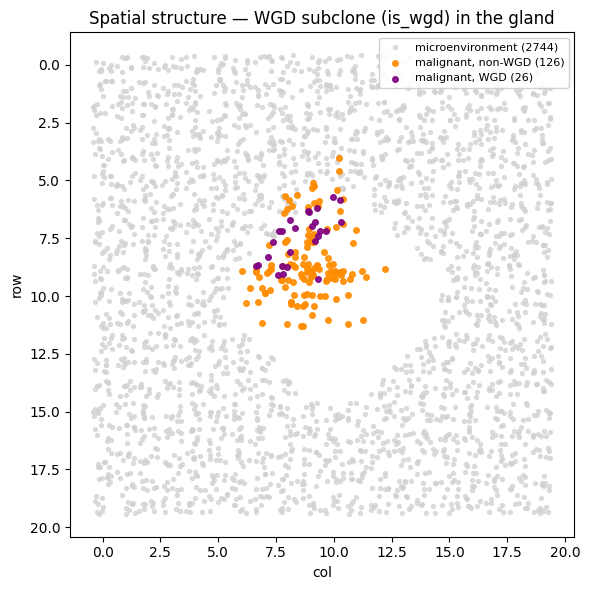

In [3]:
crd = cd["cell_crd"]
jit = np.random.default_rng(1)
jx = crd["col"].values + jit.uniform(-0.42, 0.42, len(crd))
jy = crd["row"].values + jit.uniform(-0.42, 0.42, len(crd))

fig, ax = plt.subplots(figsize=(6.4, 6))
norm = ~is_cancer
ax.scatter(jx[norm], jy[norm], s=8, c="0.82", alpha=0.7, label=f"microenvironment ({norm.sum()})")
mc_nw = is_cancer & ~is_wgd
mc_w = is_cancer & is_wgd
ax.scatter(jx[mc_nw], jy[mc_nw], s=16, c="darkorange", alpha=0.9, label=f"malignant, non-WGD ({mc_nw.sum()})")
ax.scatter(jx[mc_w], jy[mc_w], s=16, c="purple", alpha=0.9, label=f"malignant, WGD ({mc_w.sum()})")
ax.set_aspect("equal"); ax.invert_yaxis()
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.set_title("Spatial structure — WGD subclone (is_wgd) in the gland")
ax.set_xlabel("col"); ax.set_ylabel("row")
plt.tight_layout()

## 3. The ploidy signature of WGD

Averaging total copy number over the genome gives a per-cell **ploidy** proxy. Across the *whole
mixture* it is trimodal: the diploid microenvironment anchors at ~2; the malignant cells split into a
**near-diploid non-WGD** mode and an **elevated WGD** mode — the doubling (then partial loss) pushes
WGD cells well above ploidy 2. The normal anchor at 2 is the reference point a caller uses to place the
tumour on this axis.

mean ploidy     normal: 2.00
mean ploidy    non-WGD: 1.81
mean ploidy        WGD: 3.78


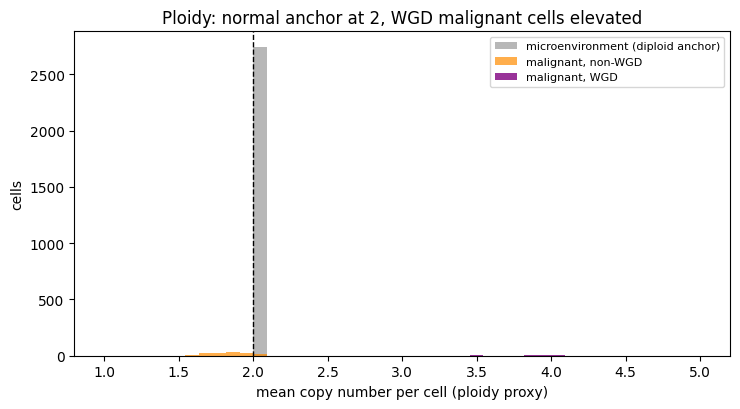

In [4]:
ploidy = cd["cell_cnv"].values.mean(1)      # per-cell mean total CN ~ ploidy
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bins = np.linspace(1, 5, 45)
ax.hist(ploidy[~is_cancer], bins=bins, alpha=0.7, color="0.6", label=f"microenvironment (diploid anchor)")
ax.hist(ploidy[is_cancer & ~is_wgd], bins=bins, alpha=0.7, color="darkorange", label="malignant, non-WGD")
ax.hist(ploidy[is_cancer & is_wgd], bins=bins, alpha=0.8, color="purple", label="malignant, WGD")
ax.axvline(2, color="k", ls="--", lw=1)
ax.set_xlabel("mean copy number per cell (ploidy proxy)"); ax.set_ylabel("cells")
ax.set_title("Ploidy: normal anchor at 2, WGD malignant cells elevated")
ax.legend(fontsize=8)
for lbl, m in [("normal", ~is_cancer), ("non-WGD", is_cancer & ~is_wgd), ("WGD", is_cancer & is_wgd)]:
    print(f"mean ploidy  {lbl:>9}: {ploidy[m].mean():.2f}")
plt.tight_layout()

## 4. Why total copy number alone misses WGD

A *pure* doubling multiplies every homolog by the same factor: $1{+}1 \to 2{+}2$. Two consequences:

* **BAF stays 0.5** — both homologs doubled equally, so the allele fractions are unchanged.
* Under per-cell depth normalisation (every caller does this — depth is *relative*), a genome-wide
  factor of 2 **cancels**: $2{+}2$ normalises back to look like $1{+}1$.

So a pure doubling is essentially **unidentifiable** from total CN *and* from BAF. The only thing that
breaks the symmetry is a **subsequent loss**: $2{+}2 \to 3{+}1$ (or $4{+}0$) keeps the total **even**
(4, still total-CN-ambiguous with $2{+}2$) but makes it allelically **imbalanced** — and *that* the
allele layer can see. We quantify exactly this next.

## 5. WGD manufactures allele-only-detectable states (cohort contrast)

Define an **allele-only-detectable** segment as one that is allelically imbalanced ($|p-m|\ge 1$) yet
has an **even total** copy number — a state a total-CN-blind caller cannot flag but an allele-aware one
can. We grow a small cohort of tumours with WGD **off** vs **on** and measure the fraction of malignant
segments in this state. (WGD-off and WGD-on are different RNG trajectories — the doubling draw shifts
the random stream — so we average over seeds and read it as a **cohort contrast**, not a paired diff.)
This is the ground-truth version of Numbat's headline panel: the imbalanced-even states it exploits are
**rare without WGD and several-fold more common with it**.

WGD off (wgd_rate=0.00): per-seed [0.01, 0.015, 0.005, 0.012]  mean 0.010
WGD on  (wgd_rate=0.05): per-seed [0.065, 0.017, 0.067, 0.036]  mean 0.046


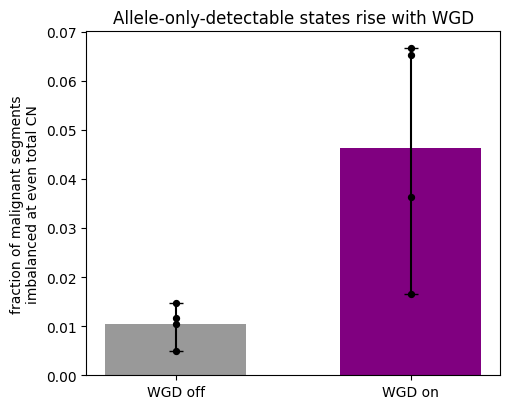

In [5]:
def grow_variant(seed, wgd_rate, steps=1200):
    cancer = dict(CANCER); cancer["wgd_rate"] = wgd_rate
    tt = GenotypeTumor(seed=seed, genome_params=GENOME, selection_params=SELECTION,
                       cancer_cell_params=cancer, deme_params=DEME, spatial_params=SPATIAL,
                       expression_params=EXPR)
    tt.grow(n_steps=steps, seed=seed); tt.make_cell_data()
    return tt

def allele_only_detectable_frac(tt):
    '''fraction of malignant segments that are imbalanced (|p-m|>=1) at EVEN total CN.'''
    ac = segment_allele_cn(tt); ty = cell_types(tt)
    ids = np.asarray(tt.cell_data["cell_type"].index)[ty == "cancer"]
    tot = imb = 0
    for c in ids:
        a = ac[c]
        if a is None:
            continue
        p, m = a[:, 0], a[:, 1]; total = p + m
        even = (total % 2 == 0) & (total > 0)
        tot += int(even.sum()); imb += int(((np.abs(p - m) >= 1) & even).sum())
    return imb / max(tot, 1)

seeds = [1, 2, 3, 4]
res = {0.0: [], 0.05: []}
for wr in res:
    for s in seeds:
        res[wr].append(allele_only_detectable_frac(grow_variant(s, wr)))
off, on = np.array(res[0.0]), np.array(res[0.05])
print(f"WGD off (wgd_rate=0.00): per-seed {np.round(off,3).tolist()}  mean {off.mean():.3f}")
print(f"WGD on  (wgd_rate=0.05): per-seed {np.round(on,3).tolist()}  mean {on.mean():.3f}")

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.bar([0, 1], [off.mean(), on.mean()], color=["0.6", "purple"], width=0.6,
       yerr=[[off.mean()-off.min(), on.mean()-on.min()], [off.max()-off.mean(), on.max()-on.mean()]],
       capsize=5)
ax.scatter(np.zeros_like(off), off, c="k", s=18, zorder=3)
ax.scatter(np.ones_like(on), on, c="k", s=18, zorder=3)
ax.set_xticks([0, 1]); ax.set_xticklabels(["WGD off", "WGD on"])
ax.set_ylabel("fraction of malignant segments\nimbalanced at even total CN")
ax.set_title("Allele-only-detectable states rise with WGD")
plt.tight_layout()

## 6. The emergent allele signal (BAF)

The imbalance is not just in the latent genome — it **propagates to expression**. iscc's per-cell RNA
B-allele frequency (`cell_rna_baf`, from the allele-resolved dosage model) departs from 0.5 exactly at
the imbalanced segments of malignant cells, while the diploid microenvironment stays balanced at 0.5.
That contrast — imbalance **localised to the malignant CNAs**, normal cells flat at 0.5 — is what makes
the allele signal callable at all. (`cell_rna_baf` is the *latent* per-cell BAF; a real assay adds
Binomial sampling noise on top, which is what Numbat's allele counts carry.)

|BAF-0.5|  malignant imbalanced segments: 0.352
|BAF-0.5|  malignant balanced   segments: 0.000
|BAF-0.5|  normal cells (anchor)        : 0.000


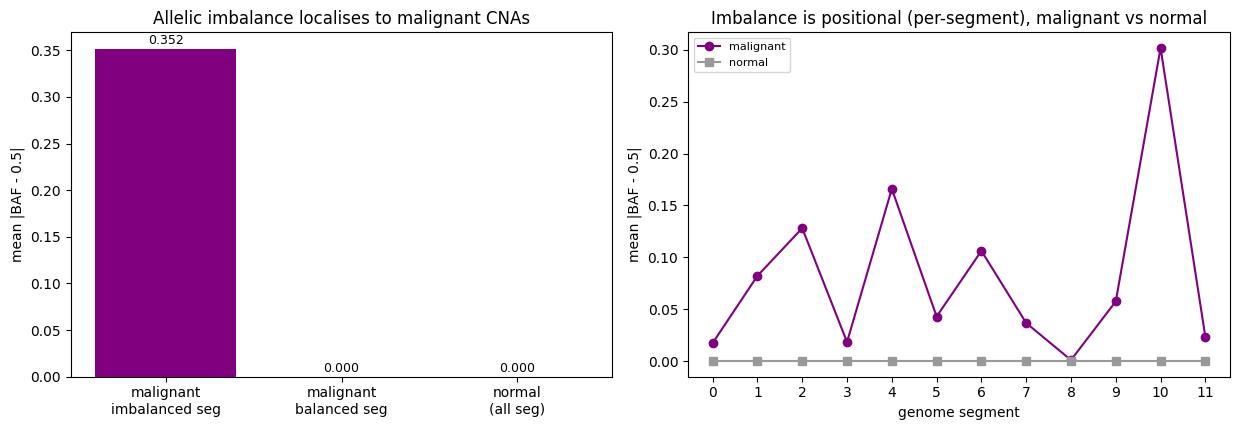

In [6]:
baf = np.abs(cd["cell_rna_baf"].values - 0.5)      # |BAF - 0.5|, per cell per gene
gseg = segment_gene_map(t)
ac = segment_allele_cn(t)

imb_mal, bal_mal, normal_vals = [], [], []
per_seg_mal = np.zeros(t.n_segments); per_seg_mal_n = np.zeros(t.n_segments)
per_seg_norm = np.zeros(t.n_segments); per_seg_norm_n = np.zeros(t.n_segments)
for i in mix_pos:
    c = idx[i]; row = baf[i]
    if not is_cancer[i]:
        normal_vals.extend(row.tolist())
        for s in range(t.n_segments):
            per_seg_norm[s] += row[gseg == s].sum(); per_seg_norm_n[s] += (gseg == s).sum()
        continue
    a = ac[c]; imb_seg = (np.abs(a[:, 0] - a[:, 1]) >= 1)
    gene_imb = imb_seg[gseg]
    imb_mal.extend(row[gene_imb].tolist()); bal_mal.extend(row[~gene_imb].tolist())
    for s in range(t.n_segments):
        per_seg_mal[s] += row[gseg == s].sum(); per_seg_mal_n[s] += (gseg == s).sum()

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
groups = ["malignant\nimbalanced seg", "malignant\nbalanced seg", "normal\n(all seg)"]
means = [np.mean(imb_mal), np.mean(bal_mal), np.mean(normal_vals)]
axes[0].bar(groups, means, color=["purple", "darkorange", "0.6"])
axes[0].set_ylabel("mean |BAF - 0.5|")
axes[0].set_title("Allelic imbalance localises to malignant CNAs")
for i, v in enumerate(means):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

axes[1].plot(range(t.n_segments), per_seg_mal / np.maximum(per_seg_mal_n, 1), "o-",
             color="purple", label="malignant")
axes[1].plot(range(t.n_segments), per_seg_norm / np.maximum(per_seg_norm_n, 1), "s-",
             color="0.6", label="normal")
axes[1].set_xlabel("genome segment"); axes[1].set_ylabel("mean |BAF - 0.5|")
axes[1].set_title("Imbalance is positional (per-segment), malignant vs normal")
axes[1].legend(fontsize=8); axes[1].set_xticks(range(t.n_segments))
plt.tight_layout()
print(f"|BAF-0.5|  malignant imbalanced segments: {np.mean(imb_mal):.3f}")
print(f"|BAF-0.5|  malignant balanced   segments: {np.mean(bal_mal):.3f}")
print(f"|BAF-0.5|  normal cells (anchor)        : {np.mean(normal_vals):.3f}")

## What this shows

* WGD is a **first-class event** in iscc (`wgd_rate`, `is_wgd`), producing the characteristic
  **elevated-ploidy** subclone against the diploid normal anchor.
* A *pure* doubling ($2{+}2$) is allelically **balanced** and cancels under per-cell normalisation — so
  it is **unidentifiable from total copy number and BAF alike**. Only the **doubling + loss** erosion
  ($3{+}1$ / $4{+}0$) creates an **even-total, allelically-imbalanced** state.
* Those states are **rare without WGD, several-fold more common with it**, and the imbalance
  **propagates to the RNA BAF**, localised to the malignant CNAs — the exact signal an allele-aware
  caller reads and an expression-only one cannot.

**Next / see also:**
[`notebooks/assay_dna.ipynb`](assay_dna.ipynb) (coverage / VAF / ADO) ·
[`notebooks/combining_scdna_scrna.ipynb`](combining_scdna_scrna.ipynb) (scDNA↔scRNA integration) ·
the full **Numbat vs inferCNV** head-to-head (where Numbat recovers this allelic state and
expression-only inferCNV is at chance): `validation/validate_numbat.py --wgd-rate 0.04`.